# Exercises for Thursday afternoon

In this exercise you will perform a complete calculation for approximating time dependent expectation values of the form 

$$O(t) = \langle\Psi_0\lvert \hat{O}(t)\rvert \Psi_0\rangle = \langle\Psi_0\lvert\exp(it\hat{H}) \hat{O}\exp(-it\hat{H})\rvert \Psi_0\rangle$$

With an Ising Hamiltonian given by

$$H=-\sum_{j=0}^{N-1}Z_j+J\sum_{j=0}^{N-2}X_jX_{j+1}$$

and an initial state $\rvert \Psi_0\rangle$ obtained from VQE. The goal is to be able to successfully mitigate the systematic errors coming from the noise in the quantum hardware without necessarily worrying too much about the (possibly larger) systematic errors coming from the difference between the actual ground-state of $H$ and our approximation $\rvert \Psi_0\rangle$ and our approximation of the time evolution operator $\exp(-it\hat{H})$. 

Much of what you'll need has been explained and demonstrated in the notebook `ErrorMitigation-Gates` for the case $N=2$ and $J=1$.

This afternoon your goal is to use instead $N=3$ and $J=2$ and measure the following observables

- $O_0(t)=<Z_0(t)>$, $O_1(t)=<Z_1(t)>$, $O_2(t)=<Z_2(t)>$  
- $O_3(t)=<(Z_0+Z_1+Z_2)(t)>$  
- $O_4(t)=<Z_0Z_1Z_2(t)>$  
- $O_5(t)=<Z_0Z_1(t)>-O_0(t)O_1(t)$  
- $O_6(t)=<Z_0Z_2(t)>-O_0(t)O_2(t)$  
- $O_7(t)=<Z_1Z_2(t)>-O_1(t)O_2(t)$  

The steps are as follows

1. use the simple variational ansatz we used in the morning to determine the optimal rotation angle $\theta$
2. implement the exact time evolution to have a reference (look below if you want to skip this step and use our implementation)
3. implement a second order Trotter approximation of the evolution so that you can benchmark your circuit implementation
4. implement circuits for the second order Trotter approximation of the evolution and verify they are correct using a state vector simulation
5. implement the full protocol of error mitigation (read out and gates) for the circuits you just used at the step above
6. run the circuits with error mitigation on a noise emulator and check they work as expected, if they do run on hardware

Since this is a more challanging simulation than the $N=2$ case explored in the `ErrorMitigation-Gates` notebook we **strongly suggest** to use, as a first step, a simulation where the number of steps is fixed to some values $N_S$ for all times $t$ and you instead change the time-step as $dt=t/N_S$. In this way the error will grow faster in time but at least the depth will be under control. You should try to aim at time intervals like $[0,2]$ or $[0,4]$ with $N_S=4$ and $N_S=8$. Check first how accurate these are compared to a fixed step Trotter evolution and perform a calculation over $20$ time values (for a total of $40$ independent circuits). 

In the latter case, and for the $[0,4]$ time interval, a step $dt=0.1$ is reasonable while with $dt=0.05$ the systematic errors become rather small (but the depth becomes considerably larger...).

-----------------------------------------------------------------------------------------------------------------------

### Exact calculation for reference

First let's define a few useful things below

In [1]:
import numpy as np
import scipy as sp

# we start defining all the Pauli observables we might need
I = np.eye(2)
X = np.array([[0,1],[1,0]],dtype=complex)
Y = np.array([[0,-1.j],[1.j,0]],dtype=complex)
Z = np.array([[1,0],[0,-1]],dtype=complex)
X_2 = np.kron(np.kron(X,I),I); Y_2 = np.kron(np.kron(Y,I),I); Z_2 = np.kron(np.kron(Z,I),I)
X_1 = np.kron(np.kron(I,X),I); Y_1 = np.kron(np.kron(I,Y),I); Z_1 = np.kron(np.kron(I,Z),I)
X_0 = np.kron(np.kron(I,I),X); Y_0 = np.kron(np.kron(I,I),Y); Z_0 = np.kron(np.kron(I,I),Z)

X_0X_1 = np.kron(np.kron(I,X),X); Z_0Z_1 = np.kron(np.kron(I,Z),Z); Z_0Z_2 = np.kron(np.kron(Z,I),Z)
X_1X_2 = np.kron(np.kron(X,X),I); Z_1Z_2 = np.kron(np.kron(Z,Z),I)
X_0X_1X_2 = np.kron(np.kron(X,X),X); Z_0Z_1Z_2 = np.kron(np.kron(Z,Z),Z)
X_0Y_1 = np.kron(np.kron(I,Y),X); X_1Y_2 = np.kron(np.kron(Y,X),I)

## This produces the state \Psi(theta) with the ansatz from this morning
def get_initial_state3(theta_angle):
    # these are the computational states
    zero_state=np.array([1,0])
    one_state=np.array([0,1])
    ## exact state prep
    init_state = np.kron(zero_state,np.kron(zero_state,zero_state))
    ## rotation on 01
    r01 = np.cos(theta_angle)*np.eye(8)-1.j*np.sin(theta_angle)*X_0Y_1
    ## rotation on 12
    r12 = np.cos(theta_angle)*np.eye(8)-1.j*np.sin(theta_angle)*X_1Y_2
    ## state
    return r12@r01@init_state

## Returns the energy expectation value for a given input state
def calc_energy3(state,J=1.0):
    H3 = -Z_0-Z_1-Z_2+J*(X_0X_1+X_1X_2)
    return np.real(np.vdot(state,H3@state))
    
## This evolves our initial ansatz state forward in time
## NOTE: 'times' is a list of times we want
def get_evolved_states3(angle, times, J=1.0):
    # get initial state
    init_state = get_initial_state3(angle)
    # get Hamiltonian
    H3 = -Z_0-Z_1-Z_2+J*(X_0X_1+X_1X_2)
    # evolved states
    states = []
    for time in times:
        # exact evolution operator
        propt = sp.linalg.expm(-1.j*time*H3)
        # exact evolved state
        state_of_t = propt@init_state
        # append to list
        states.append(state_of_t)
    return states

## Compute a list of observables an a fixed state
def get_observables(state, obs_list):
    exp_values = []
    for oo in obs_list:
        exp_now = np.real(np.vdot(state,oo@state))
        exp_values.append(exp_now)
    return exp_values

At this point we choose a value for $J$, a value for the angle $\theta$ (which you should optimize yourself) and a list of observables we want to estimate. 

For $J=2$ a value $\theta=-0.5$ is not too bad (you should do better).

In [2]:
## Hamiltonian and state parameters
J_ham = 2.0
theta_angle = -0.5

## Observables
zobs = [Z_0, Z_1, Z_2, Z_0Z_1, Z_1Z_2, Z_0Z_2, Z_0Z_1Z_2]
num_zobs = len(zobs)

## times
num_times = 1000
times = np.linspace(0,4,num_times)

evolved_states = get_evolved_states3(theta_angle,times,J=J_ham)
                                     
zobs_results = np.zeros((num_times,num_zobs))
for rr in range(num_times):
    zobs_results[rr,:] = np.array(get_observables(evolved_states[rr],zobs))

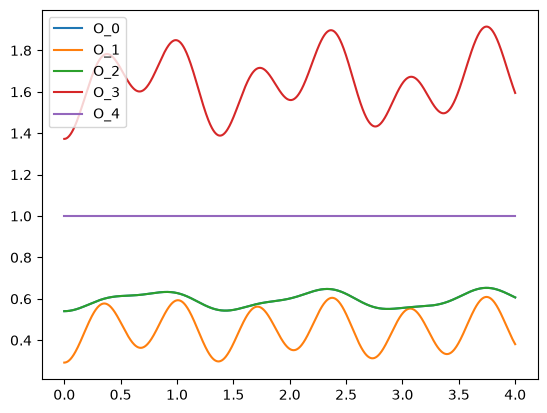

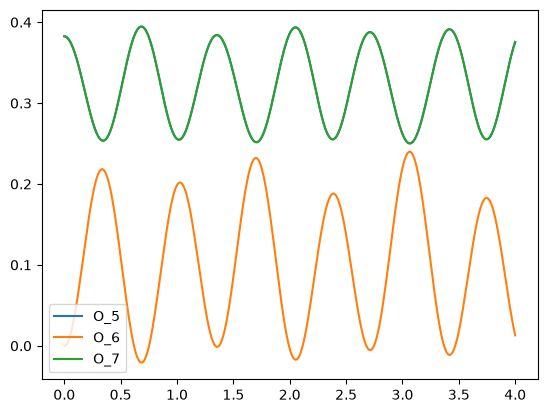

In [3]:
import matplotlib.pyplot as plt

plt.plot(times, zobs_results[:,0], label="O_0")
plt.plot(times, zobs_results[:,1], label="O_1")
plt.plot(times, zobs_results[:,2], label="O_2")
plt.plot(times, zobs_results[:,0]+zobs_results[:,1]+zobs_results[:,2], label="O_3")
plt.plot(times, zobs_results[:,6], label="O_4")
plt.legend()
plt.show()
plt.plot(times, zobs_results[:,3]-zobs_results[:,0]*zobs_results[:,1], label="O_5")
plt.plot(times, zobs_results[:,5]-zobs_results[:,0]*zobs_results[:,2], label="O_6")
plt.plot(times, zobs_results[:,4]-zobs_results[:,1]*zobs_results[:,2], label="O_7")
plt.legend()
plt.show()